In [2]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Loading dataset

df = pd.read_csv(r"C:\Users\ayush kumar gupta\OneDrive\Desktop\user_reviews.csv")

df.head(10)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [5]:
# Checking shape of dataset

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Shape of Dataset:
(64295, 5)

Column Names:
Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [7]:
# Checking missing values

df.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [ ]:
## Step 3: Handling Missing Values

The dataset contains some missing reviews and sentiment values.

Since these records cannot be used for training, they will be removed.

In [8]:
# Removing rows where review or sentiment is missing

df = df.dropna(
    subset=[
        "Translated_Review",
        "Sentiment"
    ]
)

print("Dataset Shape After Cleaning:")
print(df.shape)

Dataset Shape After Cleaning:
(37427, 5)


In [ ]:
## Step 4: Sentiment Distribution

Visualizing the number of Positive, Negative and Neutral reviews.

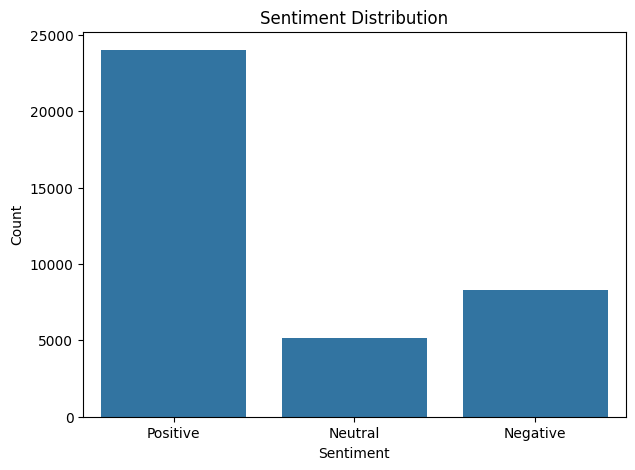

In [9]:
# Count plot of sentiments

plt.figure(figsize=(7,5))

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [ ]:
## Step 5: Text Preprocessing

Cleaning review text using NLP techniques.

The following operations are performed:

- Convert text to lowercase
- Remove URLs
- Remove numbers
- Remove punctuation
- Remove extra spaces

In [10]:
# Function for text cleaning

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = text.strip()

    return text

In [11]:
# Applying text cleaning

df["Clean_Review"] = df["Translated_Review"].apply(clean_text)

df[["Translated_Review","Clean_Review"]].head()

,Translated_Review,Clean_Review
0,I like eat delicious food. That's I'm cooking ...,i like eat delicious food thats im cooking foo...
1,This help eating healthy exercise regular basis,this help eating healthy exercise regular basis
3,Works great especially going grocery store,works great especially going grocery store
4,Best idea us,best idea us
5,Best way,best way


In [ ]:
## Step 6: Feature Engineering Using TF-IDF

Machine learning algorithms cannot understand text directly.

TF-IDF converts review text into numerical features which can be used by machine learning models.

In [12]:
# Creating features and target variable

X = df["Clean_Review"]

y = df["Sentiment"]

# Applying TF-IDF

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(X)

print("Feature Matrix Shape:")
print(X.shape)

Feature Matrix Shape:
(37427, 5000)


In [ ]:
## Step 7: Splitting Dataset

Splitting the dataset into training and testing sets.

- 80% Training Data
- 20% Testing Data

In [13]:
# Splitting data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (29941, 5000)
Testing Data Shape: (7486, 5000)


In [ ]:
## Step 8: Naive Bayes Model

Training the Naive Bayes classifier and evaluating its performance.

In [14]:
# Creating Naive Bayes model

nb_model = MultinomialNB()

# Training model

nb_model.fit(X_train, y_train)

# Predictions

nb_pred = nb_model.predict(X_test)

# Accuracy

nb_acc = accuracy_score(
    y_test,
    nb_pred
)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.7404488378306171


In [ ]:
## Step 9: Logistic Regression Model

Training Logistic Regression and checking model accuracy.

In [15]:
# Creating Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000
)

# Training model

lr_model.fit(
    X_train,
    y_train
)

# Predictions

lr_pred = lr_model.predict(
    X_test
)

# Accuracy

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_acc
)

Logistic Regression Accuracy: 0.8994122361741919


In [ ]:
## Step 10: Support Vector Machine (SVM)

Training the Support Vector Machine model.

In [16]:
# Creating SVM model

svm_model = LinearSVC()

# Training model

svm_model.fit(
    X_train,
    y_train
)

# Predictions

svm_pred = svm_model.predict(
    X_test
)

# Accuracy

svm_acc = accuracy_score(
    y_test,
    svm_pred
)

print(
    "SVM Accuracy:",
    svm_acc
)

SVM Accuracy: 0.9083622762489981


In [ ]:
## Step 11: Comparing Model Performance

Comparing the accuracy of all machine learning models.

In [17]:
# Creating comparison table

results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],

    "Accuracy":[
        nb_acc,
        lr_acc,
        svm_acc
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.740449
1,Logistic Regression,0.899412
2,SVM,0.908362


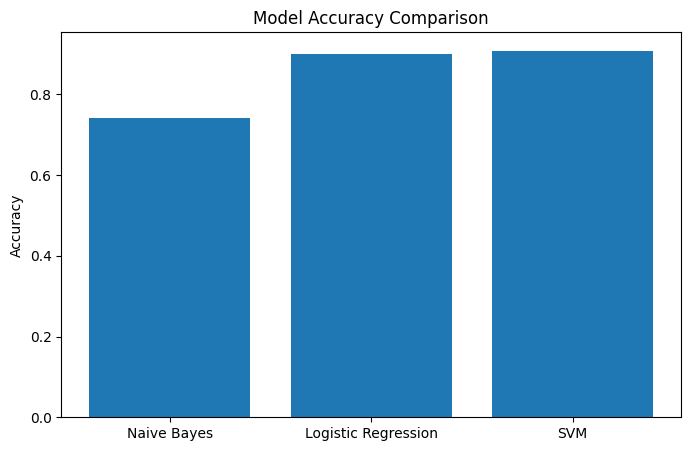

In [18]:
# Visualizing model comparison

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [ ]:
## Step 12: Classification Report

Evaluating the best model using precision, recall and F1-score.

In [19]:
# Classification report using SVM

print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.88      0.83      0.86      1653
     Neutral       0.84      0.86      0.85      1049
    Positive       0.93      0.95      0.94      4784

    accuracy                           0.91      7486
   macro avg       0.88      0.88      0.88      7486
weighted avg       0.91      0.91      0.91      7486



In [ ]:
## Step 13: Confusion Matrix

Visualizing actual and predicted sentiments.

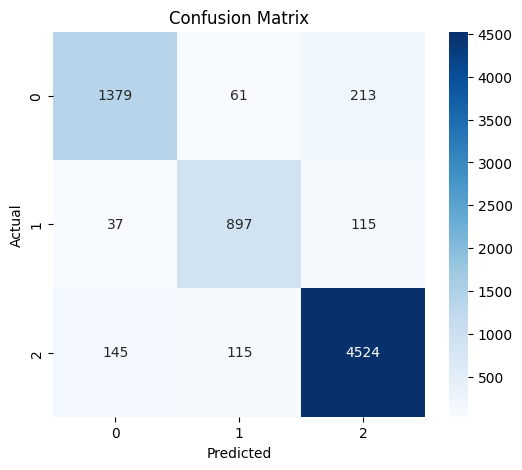

In [20]:
# Creating confusion matrix

cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [ ]:
## Step 14: Sentiment Percentage

Displaying sentiment distribution using a pie chart.

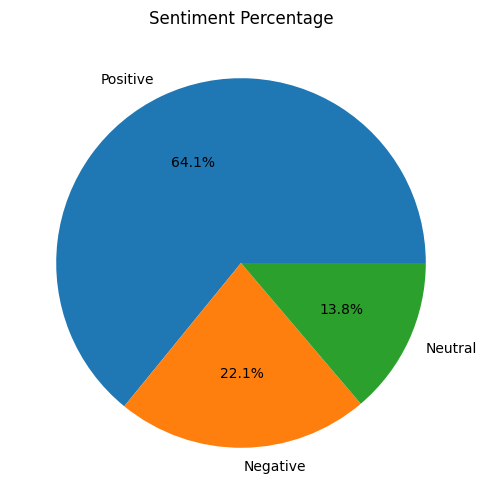

In [21]:
# Pie chart of sentiments

sentiment_counts = df[
    "Sentiment"
].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Sentiment Percentage"
)

plt.show()

In [ ]:
## Step 15: Review Length Analysis

Analyzing the length of user reviews.

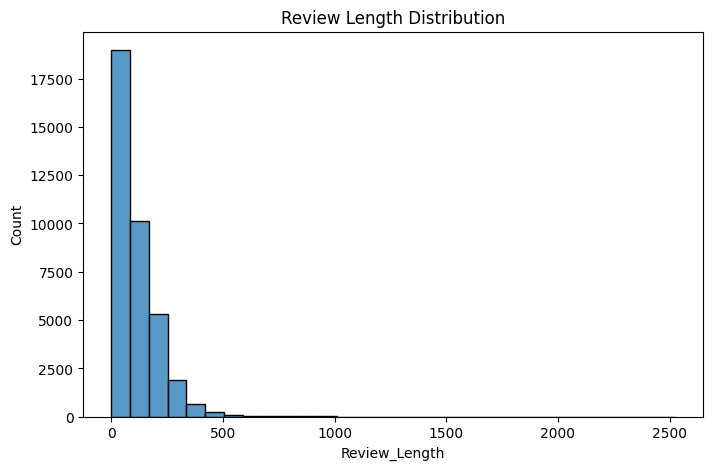

In [22]:
# Creating review length column

df["Review_Length"] = df[
    "Clean_Review"
].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    df["Review_Length"],
    bins=30
)

plt.title(
    "Review Length Distribution"
)

plt.show()

In [ ]:
## Step 16: Top 10 Apps by Number of Reviews

Finding the apps that received the most user reviews.

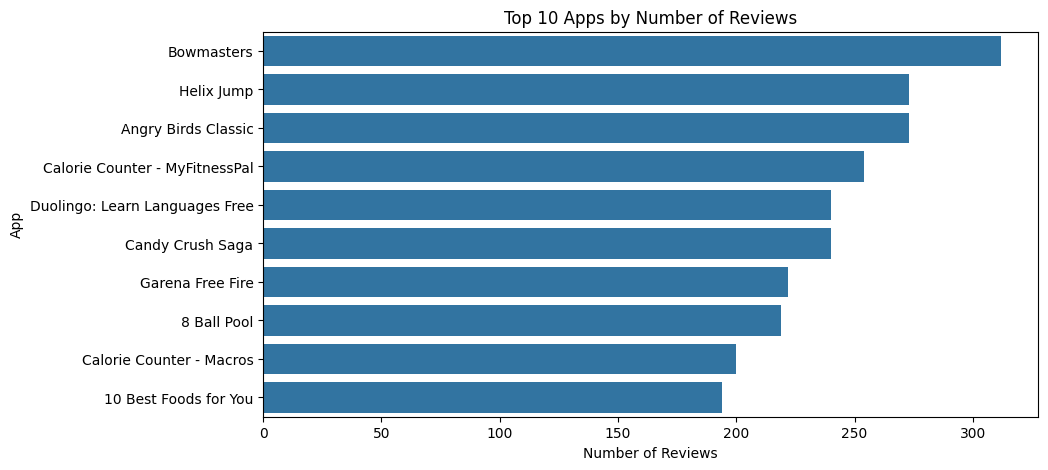

In [24]:
# Top reviewed apps

top_apps = df[
    "App"
].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_apps.values,
    y=top_apps.index
)

plt.title(
    "Top 10 Apps by Number of Reviews"
)

plt.xlabel(
    "Number of Reviews"
)

plt.ylabel(
    "App"
)

plt.show()

In [ ]:
## Step 17: Custom Sentiment Prediction

Testing the model on a new review.

In [25]:
# Sample review

sample_review = [
    "This app is amazing and very useful"
]

# Convert to TF-IDF features

sample_vector = vectorizer.transform(
    sample_review
)

# Predict sentiment

prediction = svm_model.predict(
    sample_vector
)

print(
    "Predicted Sentiment:",
    prediction[0]
)

Predicted Sentiment: Positive


In [ ]:
## Key Concepts Implemented

### 1. Sentiment Analysis
User reviews were classified into Positive, Negative and Neutral categories.

### 2. Natural Language Processing (NLP)
Text preprocessing techniques were applied to clean and prepare review data.

### 3. Machine Learning Algorithms
Naive Bayes, Logistic Regression and Support Vector Machine (SVM) models were implemented and compared.

### 4. Feature Engineering
TF-IDF Vectorization was used to transform review text into numerical features.

### 5. Data Visualization
Multiple visualizations were created including count plots, pie charts, confusion matrix, review length distribution and model comparison graphs.

In [26]:
df.to_csv(
    "cleaned_user_reviews.csv",
    index=False
)